# 01 — Feature Analysis

Explores the processed features produced by `00_data_preparation`: distribution plots,
stationarity tests (ADF), average cross-asset correlation heatmap, label balance per ticker,
and time coverage summary.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("../.." ).resolve()))
sys.path.insert(0, str(Path(".").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from config.experiment_config import TICKERS
from src.data_loader import load_processed, load_labels
from src.feature_engineering import test_distribution
from src.labeling import label_distribution, CLASS_NAMES

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

2026-04-20 02:17:10.219475: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
all_features = {}
all_labels   = {}

for ticker in tqdm(TICKERS, desc="Loading"):
    try:
        all_features[ticker] = load_processed(ticker)
        all_labels[ticker]   = load_labels(ticker)
    except FileNotFoundError:
        print(f"  {ticker}: not found \u2014 run 00_data_preparation first")

print(f"Loaded {len(all_features)} assets")
feature_cols = list(next(iter(all_features.values())).columns)
print(f"Features: {feature_cols}")

Loading:   0%|          | 0/25 [00:00<?, ?it/s]

Loaded 25 assets
Features: ['log_return_1', 'log_return_5', 'rsi_14', 'stoch_k_14', 'roc_10', 'ema_ratio_20', 'sma_ratio_50', 'macd_norm', 'macd_hist_norm', 'adx_14', 'atr_norm', 'bb_width_norm', 'bb_position', 'hv_21', 'garman_klass_vol', 'volume_ratio', 'force_index_norm', 'zscore_returns_20', 'autocorr_returns_20']


## 1. Feature Distributions

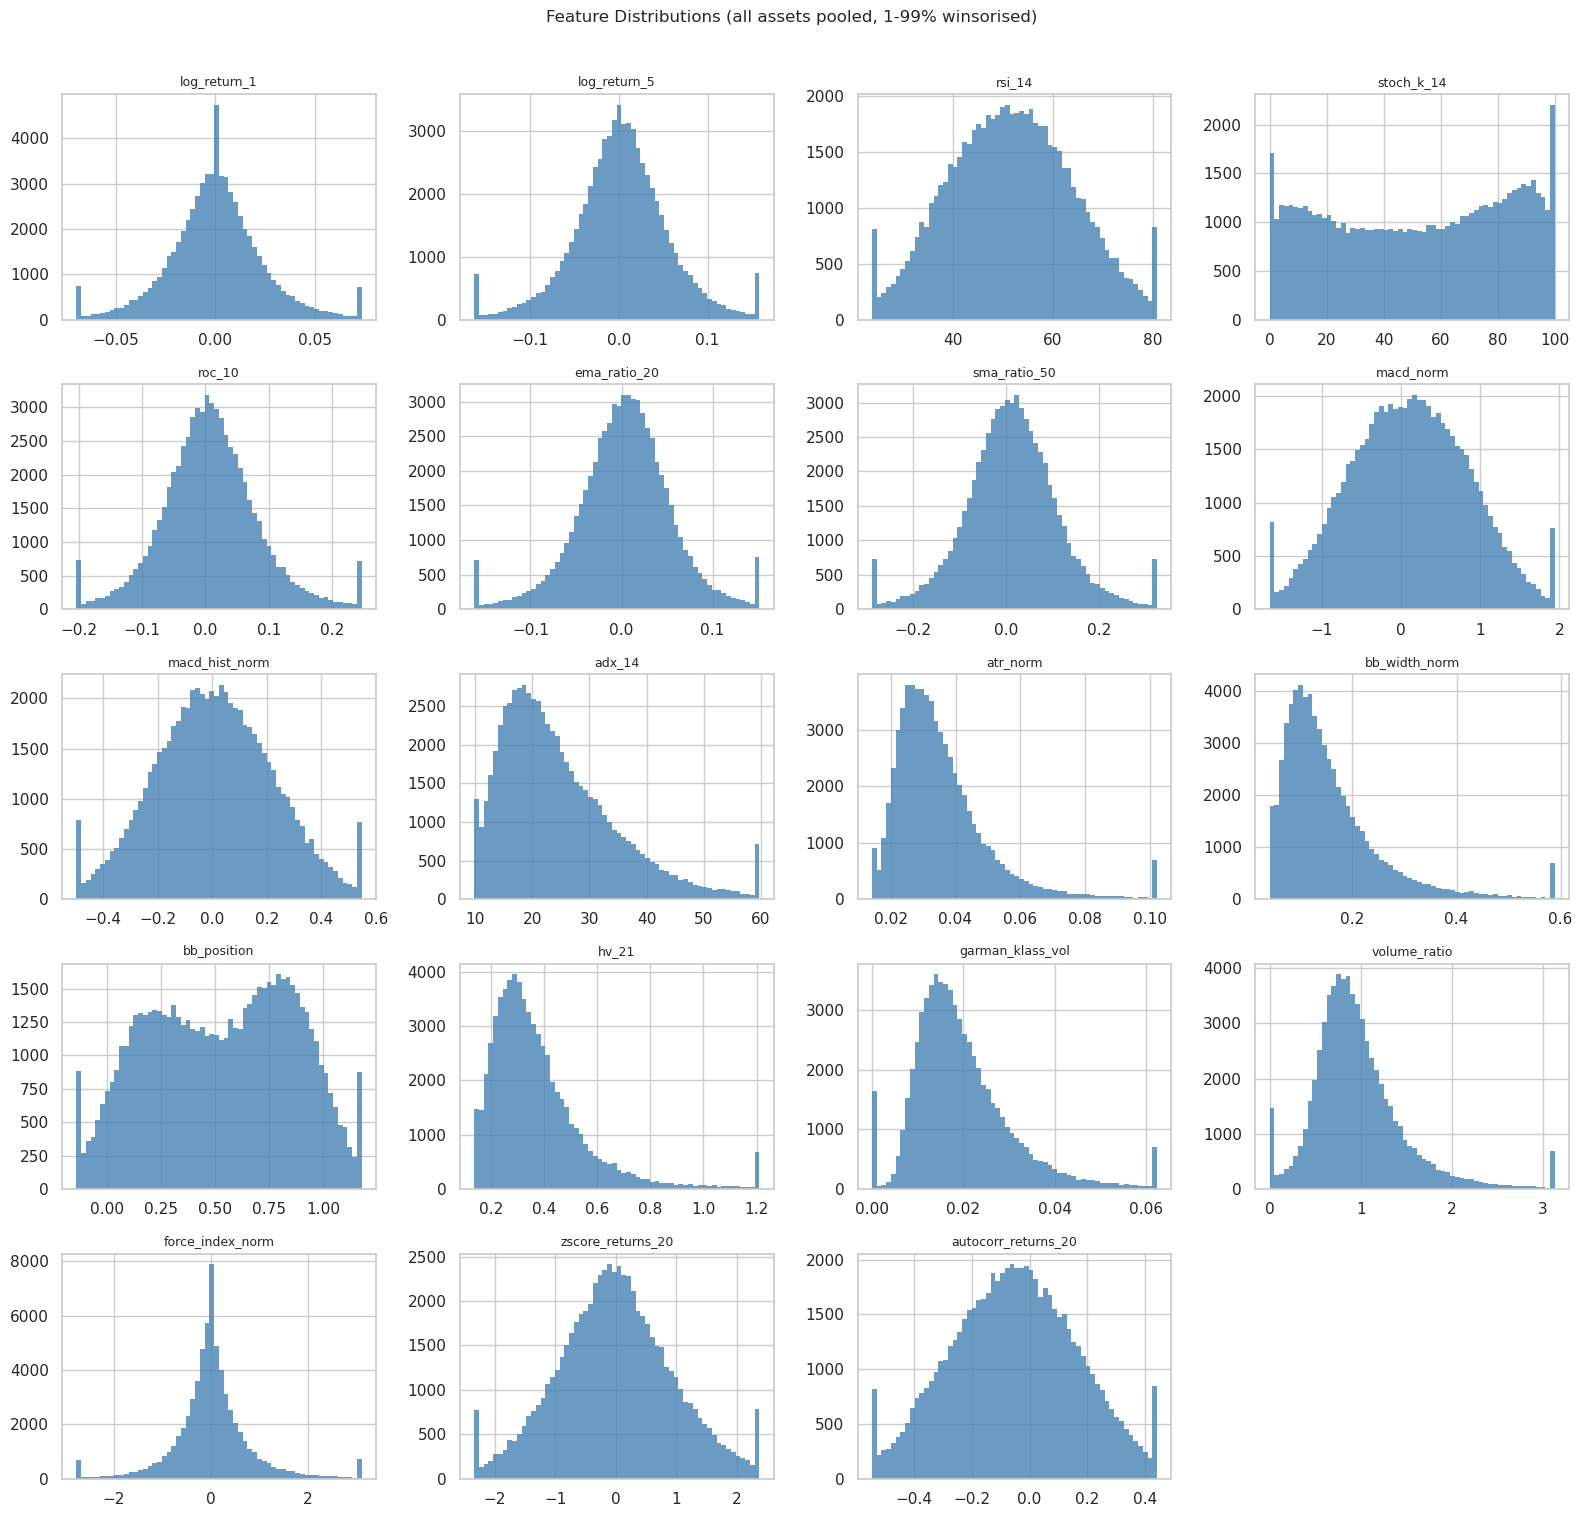

In [3]:
n_feat = len(feature_cols)
ncols = 4
nrows = (n_feat + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    # Pool all assets for combined distribution
    series = pd.concat([df[col].dropna() for df in all_features.values()])
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    p1, p99 = series.quantile([0.01, 0.99])
    series.clip(p1, p99).hist(bins=60, ax=ax, color="steelblue", edgecolor="none", alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions (all assets pooled, 1-99% winsorised)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 2. Stationarity Summary (ADF p-value per asset)

In [4]:
adf_results = {}
for col in tqdm(feature_cols, desc="ADF tests"):
    pvalues = []
    for ticker, df in all_features.items():
        if col in df.columns:
            res = test_distribution(df[col])
            pvalues.append(res["adf_pvalue"])
    adf_results[col] = pvalues

adf_df = pd.DataFrame(
    {col: {"mean_pvalue": np.mean(v), "pct_nonstationary": np.mean([p > 0.05 for p in v]) * 100}
     for col, v in adf_results.items()}
).T.round(4)

print("ADF stationarity summary:")
print(adf_df.sort_values("pct_nonstationary", ascending=False).to_string())

ADF tests:   0%|          | 0/19 [00:00<?, ?it/s]

ADF stationarity summary:
                     mean_pvalue  pct_nonstationary
log_return_1              0.0000                0.0
log_return_5              0.0000                0.0
rsi_14                    0.0000                0.0
stoch_k_14                0.0000                0.0
roc_10                    0.0000                0.0
ema_ratio_20              0.0000                0.0
sma_ratio_50              0.0000                0.0
macd_norm                 0.0000                0.0
macd_hist_norm            0.0000                0.0
adx_14                    0.0000                0.0
atr_norm                  0.0004                0.0
bb_width_norm             0.0000                0.0
bb_position               0.0000                0.0
hv_21                     0.0000                0.0
garman_klass_vol          0.0000                0.0
volume_ratio              0.0000                0.0
force_index_norm          0.0000                0.0
zscore_returns_20         0.0000      

## 3. Correlation Heatmap

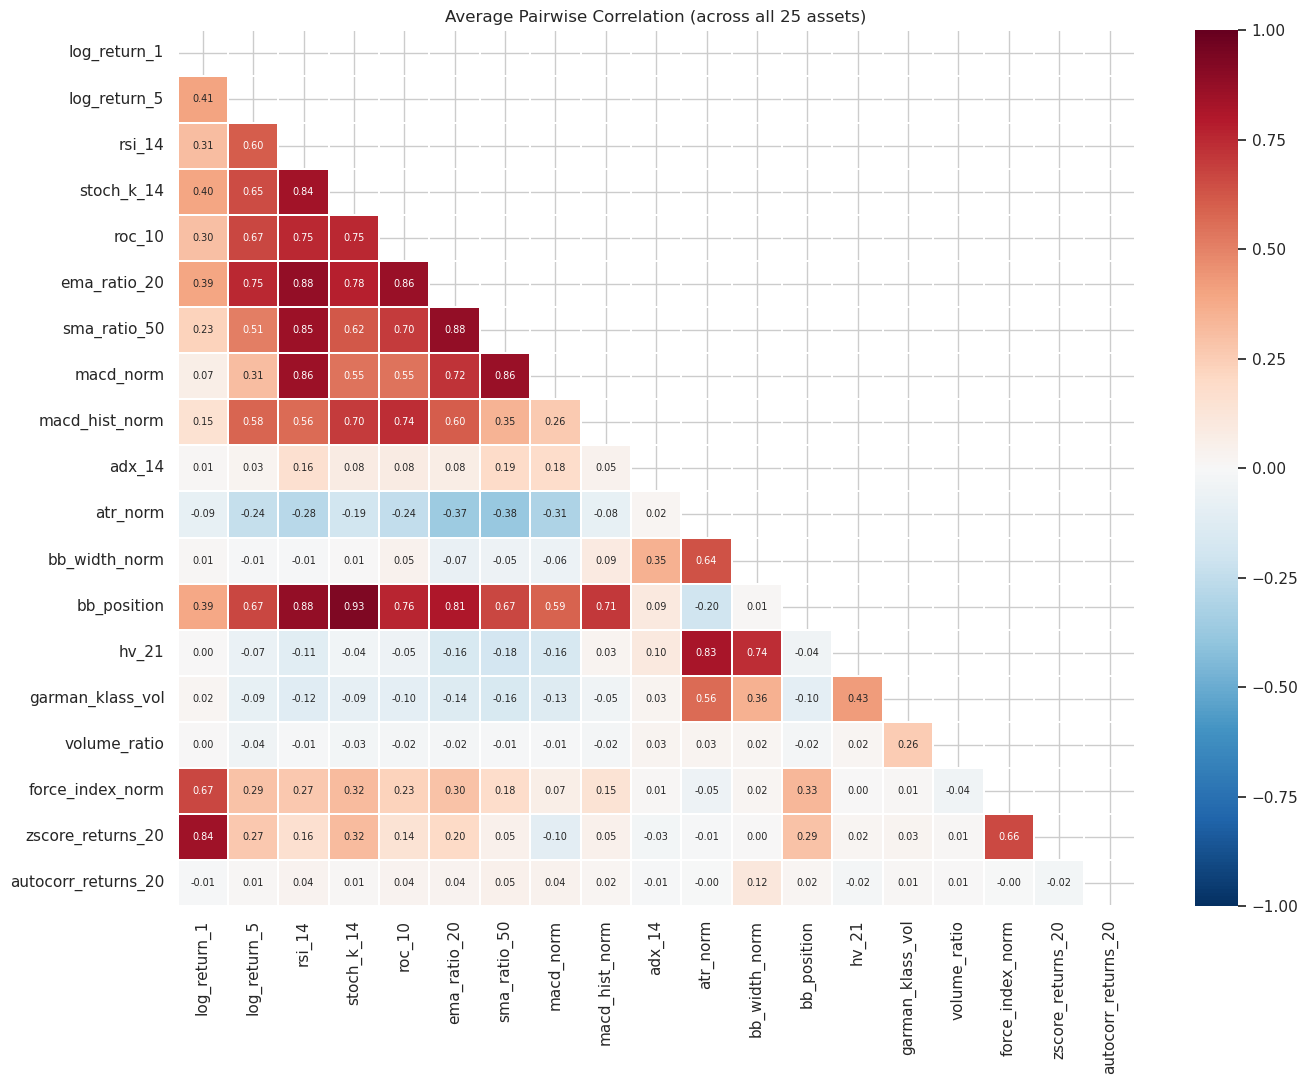

In [5]:
# Average Pearson correlation across all assets
corr_matrices = [df[feature_cols].corr() for df in all_features.values()]
avg_corr = sum(corr_matrices) / len(corr_matrices)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(avg_corr, dtype=bool))
sns.heatmap(avg_corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax, annot_kws={"size": 7})
ax.set_title("Average Pairwise Correlation (across all 25 assets)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Label Distribution per Asset

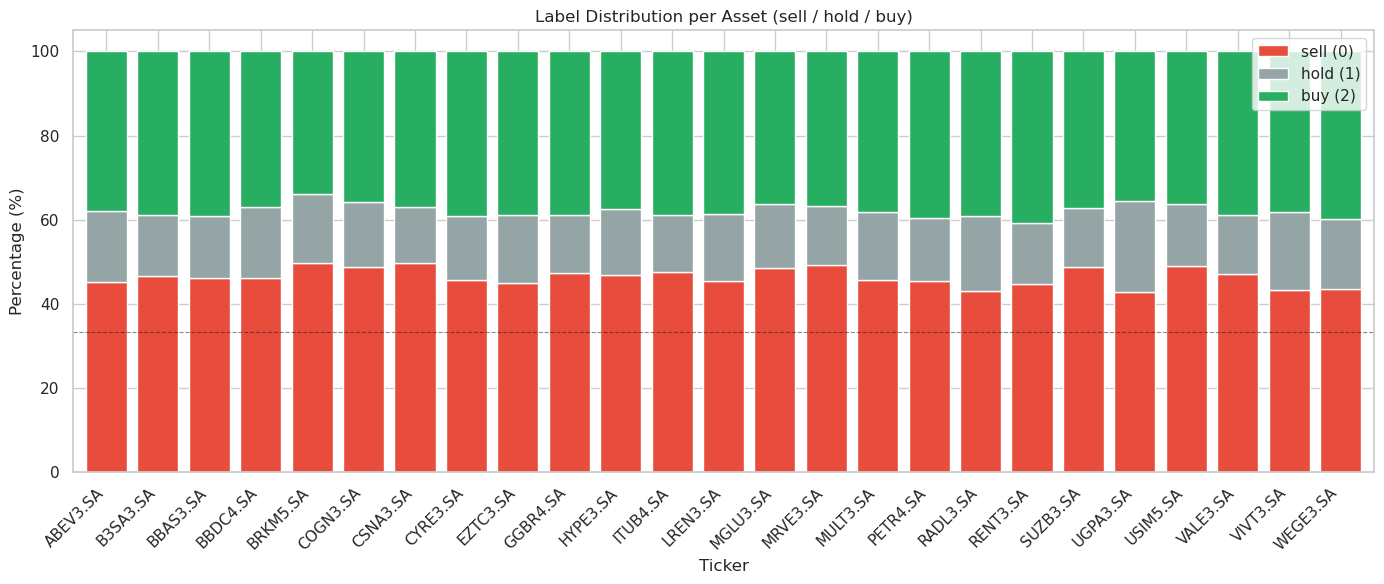


Mean across assets:
label
sell    46.4
hold    15.6
buy     37.9
dtype: float64


In [6]:
label_df = pd.DataFrame({
    ticker: label_distribution(labels)
    for ticker, labels in all_labels.items()
}).T.fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
label_df.plot(kind="bar", stacked=True, ax=ax,
              color=["#e74c3c", "#95a5a6", "#27ae60"], width=0.8)
ax.set_xlabel("Ticker")
ax.set_ylabel("Percentage (%)")
ax.set_title("Label Distribution per Asset (sell / hold / buy)")
ax.legend(["sell (0)", "hold (1)", "buy (2)"], loc="upper right")
ax.axhline(33.3, ls="--", color="k", lw=0.8, alpha=0.5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nMean across assets:")
print(label_df.mean().round(1))

## 5. Time Coverage

In [7]:
coverage = pd.DataFrame([
    {"ticker": t, "start": df.index.min(), "end": df.index.max(), "n_rows": len(df)}
    for t, df in all_features.items()
]).set_index("ticker").sort_values("n_rows", ascending=False)
print(coverage.to_string())

              start        end  n_rows
ticker                                
BRKM5.SA 2005-03-18 2026-02-06    2956
PETR4.SA 2005-03-18 2026-02-06    2956
ITUB4.SA 2005-03-18 2026-02-06    2956
USIM5.SA 2005-03-18 2026-02-06    2955
ABEV3.SA 2005-03-18 2026-02-06    2954
VALE3.SA 2005-03-18 2026-02-06    2954
BBAS3.SA 2005-03-18 2026-02-06    2954
VIVT3.SA 2005-03-18 2026-02-06    2951
CYRE3.SA 2005-03-18 2026-02-06    2948
CSNA3.SA 2005-03-18 2026-02-06    2942
RENT3.SA 2005-08-01 2026-02-06    2900
LREN3.SA 2005-04-04 2026-02-06    2881
RADL3.SA 2005-03-28 2026-02-06    2763
GGBR4.SA 2005-03-18 2026-02-06    2750
WEGE3.SA 2005-06-13 2026-02-06    2723
EZTC3.SA 2007-08-31 2026-02-06    2590
MULT3.SA 2007-10-05 2026-02-06    2581
MRVE3.SA 2007-10-01 2026-02-06    2577
B3SA3.SA 2008-01-14 2026-02-06    2546
HYPE3.SA 2008-07-01 2026-02-06    2484
BBDC4.SA 2008-03-14 2026-02-06    2451
UGPA3.SA 2007-05-08 2026-02-06    2109
MGLU3.SA 2011-07-11 2026-02-06    2065
COGN3.SA 2012-06-04 2026-